# dLEM CLI usage

`dlem` is a single-chromosome/region tool: `load_band -> fit -> optional ctcf_report ->
optional plot`. Run against the bundled example data (`data/example_chr10.cool`, paths
relative to `docs/`, where this notebook lives).


## Basic fit

Fits `L`/`R` for the whole loaded window and prints mse/corr.


In [1]:
%%bash
dlem data/example_chr10.cool /tmp/dlem_cli_basic \
    --chrom ref_region --resolution 10000 --width 700 --train-to 200


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


[dlem] NVIDIA GPU detected but JAX is running on CPU.
       For GPU acceleration reinstall with:
           pip install "dlem-jax[cuda]"

Loading ref_region @ 10000bp, width=700 from data/example_chr10.cool
[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_10000_700_1241ac6cc9d0dcc8.npy
Fitting dLEM (train_to=200, monitor=symm2, n_opt=1500)
 mse=0.1619  corr=0.7434  checkpoint=symm2
Saved fit to /tmp/dlem_cli_basic/dlem_fit.pkl


## With CTCF alignment and a plot

Adding `--ctcf-tsv` reports CTCF alignment for every checkpoint; `--plot` saves a
data-vs-prediction PNG for the given window.


In [2]:
%%bash
dlem data/example_chr10.cool /tmp/dlem_cli_full \
    --chrom ref_region --resolution 10000 --width 700 --train-to 200 \
    --ctcf-tsv data/example_ctcf.tsv \
    --plot --plot-start 150 --plot-span 200


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


[dlem] NVIDIA GPU detected but JAX is running on CPU.
       For GPU acceleration reinstall with:
           pip install "dlem-jax[cuda]"

Loading ref_region @ 10000bp, width=700 from data/example_chr10.cool
[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_10000_700_1241ac6cc9d0dcc8.npy
Fitting dLEM (train_to=200, monitor=symm2, n_opt=1500)
 mse=0.1619  corr=0.7434  checkpoint=symm2
Saved fit to /tmp/dlem_cli_full/dlem_fit.pkl
CTCF correlation (anti-correlation expected; L~CTCF+, R~CTCF-), max_lag=2:
  checkpoint    L.CTCF+  L.CTCF-  R.CTCF+  R.CTCF-
  symm2          -0.260   -0.197   -0.228   -0.263 *
Saved plot to /tmp/dlem_cli_full/prediction.png


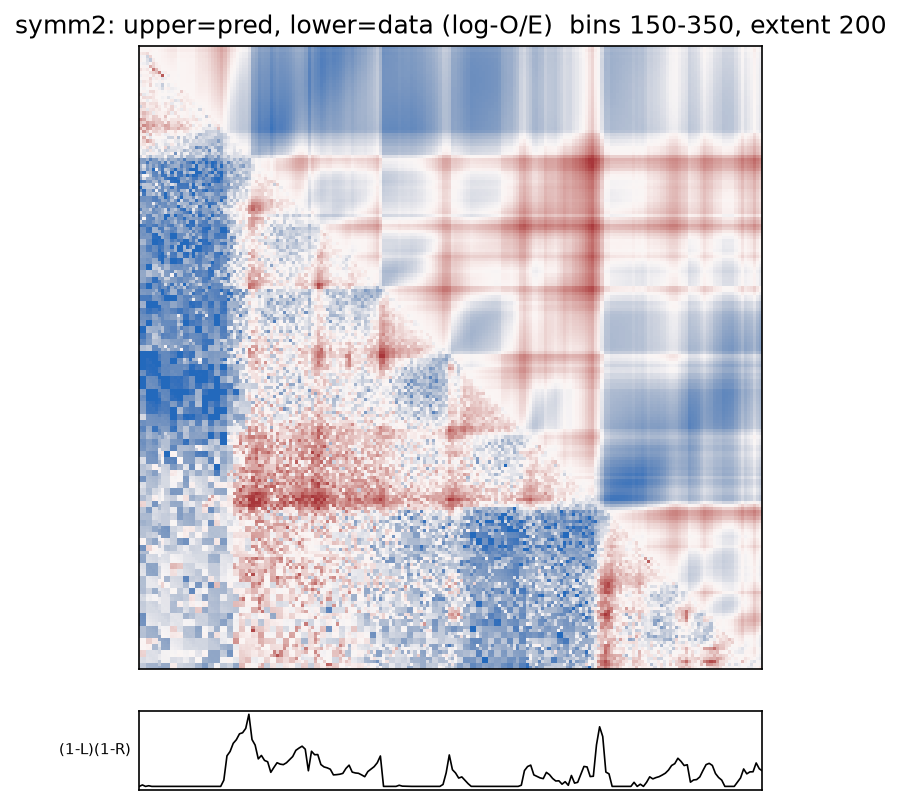

In [3]:
from IPython.display import Image, display
display(Image("/tmp/dlem_cli_full/prediction.png"))


## Output files

- `dlem_fit.pkl` -- the pickled `DlemFit` (all checkpoints, `L`/`R`, mse/corr)
- `prediction.png` -- if `--plot` was given

For anything beyond a single chromosome/region (batch fitting, track/`.cool` output),
use the `dlem` library directly -- see the Quick start tutorial.
